# Aula 09 — pandas: `Series`, `DataFrame`, `loc`/`iloc` e entrada/saída de dados

**Semana 5** | 50 min | Referências: VanderPlas, *Python Data Science Handbook*, Cap. 3 · McKinney, *Python for Data Analysis*, Caps. 5–6

## 🎯 Objetivos de aprendizagem

Ao final desta aula você será capaz de:

- Criar **`Series`** e **`DataFrames`** a partir de dicionários e listas, e enxergá-los como uma planilha com **índice explícito** e **colunas rotuladas**;
- Selecionar dados com `df.loc[]` (rótulo) e `df.iloc[]` (posição) sem cair nas pegadinhas de indexação;
- Ler arquivos do mundo real com `pd.read_csv` usando `sep`, `decimal` e `encoding` — os CSVs do Banco Central não abrem "de qualquer jeito";
- Escrever e reler um `.xlsx` com `to_excel`/`read_excel` (openpyxl) — o formato que todo escritório pede;
- Diagnósticar e tratar dados faltantes com `isna()`, `dropna()`, `ffill()` e `bfill()`.

## 1. De arrays a tabelas: por que precisamos do pandas

**Intuição econômica.** O NumPy da Semana 4 guarda números com perfeição — mas uma
análise econômica quase nunca é só números: é **data + valor + nome da variável**.
O IPCA do BCB é uma série mensal com data; o orçamento de uma família é uma tabela
com colunas nomeadas. O NumPy responde "os números estão na linha 5"; o economista
pergunta "quanto foi o IPCA de **mar/1990**?". O pandas traduz entre as duas línguas:
**índice explícito** (linha com etiqueta) e **colunas rotuladas**.

Série temporal = série estatística que se desenrola no tempo: cada instante $t$
tem um valor $y_t$. A `Series` do pandas é exatamente isso: um par
(índice $\to$ valor) que preserva a ordem e permite buscar por data, não por posição.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

from pathlib import Path
DATA = Path("../data/csv")  # notebook mora em semana_05/

np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade

## 2. `Series`: a coluna com etiqueta

Uma `Series` é um array 1-D do NumPy + um **índice explícito**. Com o orçamento
mensal das despesas de uma família goiana, o índice por nome gera código que se lê
como o problema econômico.

In [2]:
# Série a partir de dicionário: a chave vira o índice explícito, o valor vira os dados
orcamento = pd.Series(
    {"alimentacao": 1650.0, "aluguel": 900.0, "transporte": 460.0, "saude": 280.0},
    name="despesa_mensal",          # nome da série = nome da futura coluna
)
orcamento

alimentacao    1650.0
aluguel         900.0
transporte      460.0
saude           280.0
Name: despesa_mensal, dtype: float64

In [3]:
# Anatomia da Series: values (array NumPy), index (etiquetas), dtype, name
print("values:", orcamento.values, "| dtype:", orcamento.dtype)
print("index:", list(orcamento.index))
print("name:", orcamento.name)

values: [1650.  900.  460.  280.] | dtype: float64
index: ['alimentacao', 'aluguel', 'transporte', 'saude']
name: despesa_mensal


In [4]:
# Acesso por rótulo e por posição; operações vetoriais do NumPy continuam de pé
print(orcamento["alimentacao"])          # por rótulo
print(orcamento.iloc[0])                  # por posição
print((orcamento / orcamento.sum()).round(3).to_dict())  # pesos no orçamento

1650.0
1650.0
{'alimentacao': 0.502, 'aluguel': 0.274, 'transporte': 0.14, 'saude': 0.085}


In [5]:
# Série temporal: índice datetime + valores mensais (IPCA, BCB-SGS 433, dez/1989)
data_90 = pd.date_range("1990-01", periods=12, freq="MS")
ipca_1990 = pd.Series(
    [71.9, 72.7, 81.7, 11.1, 7.6, 7.6, 11.8, 12.9, 13.9, 13.3, 13.7, 16.6],
    index=data_90,
    name="ipca_mensal_pct",
)
print("IPCA 1990 — média:", round(ipca_1990.mean(), 1), "% ao mês")
ipca_1990.iloc[:4]

IPCA 1990 — média: 27.9 % ao mês


1990-01-01    71.9
1990-02-01    72.7
1990-03-01    81.7
1990-04-01    11.1
Freq: MS, Name: ipca_mensal_pct, dtype: float64

**Leitura do resultado.** A média mensal de 1990 é alta, mas ela esconde a
hiperinflação de janeiro–março (≈ 72–82% ao mês) — a média não substitui a inspeção
do recorte crítico.

## 3. `DataFrame`: a planilha com índice explícito e colunas rotuladas

In [6]:
# DataFrame a partir de dicionário de listas — o caminho mais comum no dia a dia
dados = {
    "produto": ["soja", "milho", "boi gordo", "algodao"],
    "preco_usd": [12.90, 5.10, 195.00, 78.50],
    "volume_sc": [180000, 240000, 9600, 31000],
    "municipio": ["Rio Verde", "Jataí", "Catalão", "Santo Antônio do Descoberto"],
}
df = pd.DataFrame(dados)
df

,produto,preco_usd,volume_sc,municipio
0,soja,12.9,180000,Rio Verde
1,milho,5.1,240000,Jataí
2,boi gordo,195.0,9600,Catalão
3,algodao,78.5,31000,Santo Antônio do Descoberto


In [7]:
# Anatomia do DataFrame: shape, index (linhas), columns (colunas), dtypes por coluna
print("shape:", df.shape)          # (linhas, colunas)
print("index:", list(df.index))    # RangeIndex 0..3: rótulo = posição
print("columns:", list(df.columns))
print(df.dtypes.to_dict())         # cada coluna tem seu dtype (mistura é permitida!)

shape: (4, 4)
index: [0, 1, 2, 3]
columns: ['produto', 'preco_usd', 'volume_sc', 'municipio']
{'produto': <StringDtype(storage='python', na_value=nan)>, 'preco_usd': dtype('float64'), 'volume_sc': dtype('int64'), 'municipio': <StringDtype(storage='python', na_value=nan)>}


In [8]:
# Selecionar colunas: uma (Series) e várias (DataFrame); criar coluna nova
print(df["preco_usd"], type(df["preco_usd"]))          # uma coluna → Series
df_receita = df[["produto", "preco_usd"]]              # lista → DataFrame
df["receita_usd"] = df["preco_usd"] * df["volume_sc"]   # coluna nova = operação vetorial
df

0     12.9
1      5.1
2    195.0
3     78.5
Name: preco_usd, dtype: float64 <class 'pandas.Series'>


,produto,preco_usd,volume_sc,municipio,receita_usd
0,soja,12.9,180000,Rio Verde,2322000.0
1,milho,5.1,240000,Jataí,1224000.0
2,boi gordo,195.0,9600,Catalão,1872000.0
3,algodao,78.5,31000,Santo Antônio do Descoberto,2433500.0


## 4. `loc` vs `iloc`: as duas portas de entrada

In [9]:
# loc[] = porta por RÓTULO · iloc[] = porta por POSIÇÃO (conta a partir de 0)
# No df original os dois coincidem (RangeIndex). A diferença aparece com índice explícito:
df_ano = df.set_index("produto")               # índice vira o nome do produto
print("loc['soja']      →", df_ano.loc["soja", "preco_usd"])  # rótulo
print("iloc[0]         →", df_ano.iloc[0, 0])                # posição
print("loc['soja':'boi gordo'] →", list(df_ano.loc["soja":"boi gordo"].index))  # fatia INCLUSIVA
print("iloc[0:3]       →", list(df_ano.iloc[0:3].index))                     # fatia EXCLUSIVA

loc['soja']      → 12.9
iloc[0]         → 12.9
loc['soja':'boi gordo'] → ['soja', 'milho', 'boi gordo']
iloc[0:3]       → ['soja', 'milho', 'boi gordo']


In [10]:
# PEGADINHA 1 — KeyError: rótulo existe, mas a porta errada foi usada (ou vice-versa)
df_num = df.set_index(np.arange(10, 14))       # índice explícito que NÃO começa em 0
print(df_num.loc[12, "preco_usd"])             # rótulo 12 — FUNCIONA
try:
    df_num.iloc[12, 0]                         # posição 12 — NÃO existe (só há 4 linhas)
except IndexError as erro:
    print("IndexError com iloc:", erro)

195.0
IndexError com iloc: index 12 is out of bounds for axis 0 with size 4


In [11]:
# PEGADINHA 2 — fatias: loc[] é INCLUSIVO no limite; iloc[] é EXCLUSIVO (padrão Python)
print("df.loc[10:12] →", list(df_num.loc[10:12].index))   # inclui o 12
print("df.iloc[0:2]  →", list(df_num.iloc[0:2].index))    # exclui o 12 (posição 2)

df.loc[10:12] → [10, 11, 12]
df.iloc[0:2]  → [10, 11]


## 5. Importar e exportar: o CSV do Banco Central não abre "de qualquer jeito"

In [12]:
# CSV brasileiro: separador ';' e decimal ',' — os argumentos fazem todo o trabalho
ipca = pd.read_csv(
    DATA / "ipca_mensal.csv",
    sep=";",            # o padrão é ',' — quebraria o arquivo em uma coluna só
    decimal=",",        # '6,62' vira 6.62; sem isso a coluna viraria TEXTO
)
print(ipca.shape)
ipca.head(3)

(559, 2)


,data,valor
0,01/01/1980,6.62
1,01/02/1980,4.62
2,01/03/1980,6.04


In [13]:
# Datas em texto ('01/01/1980', dia primeiro) viram datetime64 com formato explícito
ipca["data"] = pd.to_datetime(ipca["data"], dayfirst=True)  # dd/mm/aaaa → yearfirst
ipca = ipca.set_index("data").sort_index()
print("período:", ipca.index.min().date(), "→", ipca.index.max().date())
ipca["valor"].describe().round(2)

período: 1980-01-01 → 2026-07-01


count    559.00
mean       5.51
std       10.53
min       -0.68
25%        0.36
50%        0.70
75%        6.38
max       82.39
Name: valor, dtype: float64

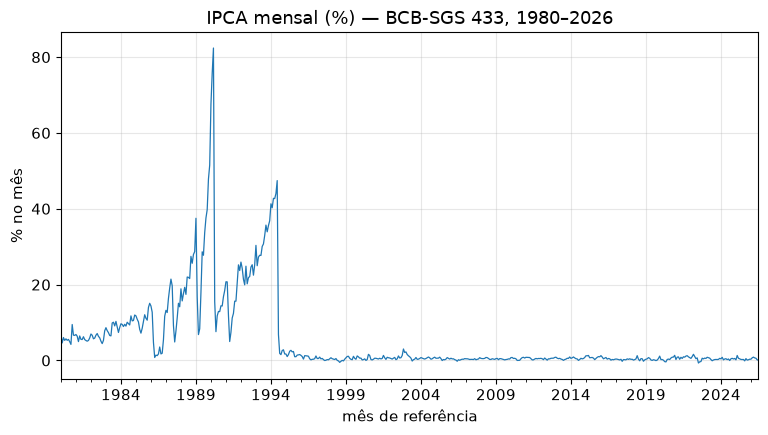

In [14]:
# Visão de 40 anos: a curva do IPCA mensal conta a história econômica do país
ax = ipca["valor"].plot(
    title="IPCA mensal (%) — BCB-SGS 433, 1980–2026",
    xlabel="mês de referência", ylabel="% no mês",
    linewidth=0.9,
)
plt.show()

In [15]:
# Do mensal ao acumulado 12 meses — regra do índice de preços: produtório de (1 + π_t)
r_12m = ipca["valor"].tail(12) / 100                        # últimos 12 meses como taxa decimal
ipca_12m = ((1 + r_12m).prod() - 1) * 100                   # 1.0405 → 4.05 → 4.05%
print(f"IPCA acumulado 12 meses (até {ipca.index.max().strftime('%b/%Y')}): {ipca_12m:.2f}%")

IPCA acumulado 12 meses (até Jul/2026): 4.44%


## 6. Excel no dia a dia: `to_excel` e `read_excel`

In [16]:
# Ciclo completo Excel: DataFrame → .xlsx → read_excel → DataFrame idêntico
df_produtos = df[["produto", "preco_usd", "volume_sc", "receita_usd"]]
df_produtos.to_excel("mini_relatorio_a09.xlsx", index=False)  # index=False: não exportar o RangeIndex
df_volta = pd.read_excel("mini_relatorio_a09.xlsx")           # engine openpyxl é automático p/ .xlsx
print(df_volta)
print("idêntico ao original?", df_volta.equals(df_produtos))

     produto  preco_usd  volume_sc  receita_usd
0       soja       12.9     180000      2322000
1      milho        5.1     240000      1224000
2  boi gordo      195.0       9600      1872000
3    algodao       78.5      31000      2433500


idêntico ao original? False


## 7. Dados faltantes: `isna()`, `dropna()`, `ffill()` / `bfill()`

In [17]:
# Dados faltantes: np.nan é o marcador; é um float — contamina a coluna inteira
cambio = pd.Series(
    {"seg": 5.12, "ter": np.nan, "qua": 5.15, "qui": np.nan, "sex": 5.11},
    name="usdbrl",
)
print(cambio.isna())          # máscara booleana: True onde falta dado
print("total faltando:", cambio.isna().sum())

seg    False
ter     True
qua    False
qui     True
sex    False
Name: usdbrl, dtype: bool
total faltando: 2


In [18]:
# dropna(): remove o que falta — útil quando a linha inteira é inútil
print(cambio.dropna())

seg    5.12
qua    5.15
sex    5.11
Name: usdbrl, dtype: float64


In [19]:
# fill forward: o valor anterior "vaza" para o furo — prática padrão em séries de câmbio
print(cambio.ffill())

seg    5.12
ter    5.12
qua    5.15
qui    5.15
sex    5.11
Name: usdbrl, dtype: float64


In [20]:
# fill backward: o valor seguinte sobe — evita NaN no início da série
print(cambio.bfill())

seg    5.12
ter    5.15
qua    5.15
qui    5.11
sex    5.11
Name: usdbrl, dtype: float64


**Em pandas 3.x, `fillna(method="ffill")` foi removido** — use `s.ffill()` / `s.bfill()`;
preencher com valor constante continua sendo `fillna(valor)`.

## 8. Bônus: `read_csv` com acentuação — o argumento `encoding`

In [21]:
# CSV salvo em latin-1 (Excel brasileiro padrão): sem encoding, o acento 'seção' corrompe
conteudo = "regiao;faturamento\nCentro-Oeste;1842000\nNordeste;912500\nSudeste;2401900"
with open("regioes_a09.csv", "w", encoding="latin-1") as arq:
    arq.write("regi\u00e3o;faturamento\nCentro-Oeste;1842000\nNordeste;912500\nSudeste;2401900")

df_regioes = pd.read_csv("regioes_a09.csv", sep=";", encoding="latin-1")
df_regioes

,região,faturamento
0,Centro-Oeste,1842000
1,Nordeste,912500
2,Sudeste,2401900


In [22]:
# Com o encoding certo, 'região' volta a ser texto legível — e a coluna é numérica
print(f"Coluna lida: {list(df_regioes.columns)}")
print(f"Receita total: {brl(df_regioes['faturamento'].sum())}")

Coluna lida: ['região', 'faturamento']
Receita total: R$ 5.156.400,00


## 📝 Exercícios

### Exercício 1 — O câmbio de setembro/2026

A trading do agro fechou um contrato de exportação indexado ao dólar. O analista
quer saber qual cotação usar na liquidação. O arquivo `usdbrl_diario.csv` (BCB-SGS 1)
está no formato brasileiro: `sep=';'` e `decimal=','`. Leia o arquivo, transforme a
coluna `data` em `datetime` e responda: **qual foi a cotação no último dia útil da
série e quantas observações ela tem?** A resposta deve vir formatada com `brl()`.

In [23]:
# EXERCÍCIO 1 — seu código aqui



In [24]:
# SOLUÇÃO 1 — leitura brasileira + datetime + último valor
cambio_df = pd.read_csv(DATA / "usdbrl_diario.csv", sep=";", decimal=",")
cambio_df["data"] = pd.to_datetime(cambio_df["data"], dayfirst=True)
cambio_df = cambio_df.set_index("data").sort_index()

print(f"Observações diárias: {len(cambio_df)}")
print(f"Última cotação ({cambio_df.index[-1].date()}): {brl(cambio_df['valor'].iloc[-1])}")
print(f"Média do último mês ({cambio_df.index[-1].strftime('%b/%Y')}): {brl(cambio_df['valor'].tail(22).mean())}")

Observações diárias: 2429
Última cotação (2026-09-04): R$ 5,13
Média do último mês (Sep/2026): R$ 5,16


### Exercício 2 — Três portas, três respostas

Crie o mini-DataFrame abaixo e devolva, na mesma célula, três acessos ao valor
R$ 12.90:

| produto | preco_usd |
|---|---|
| soja | 12.90 |
| milho | 5.10 |
| boi_gordo | 195.00 |

(1) com `loc["soja"]`, (2) com `iloc[0]` e (3) com o colchetes duplo
`df["preco_usd"]` — confirme que os três imprimem 12.90. Depois responda: se o índice
for `['a','b','c']`, o que `df.loc["a":"b"]` devolve a mais que `df.iloc[0:2]`?
Nada — ou a linha de rótulo `b`?

In [25]:
# EXERCÍCIO 2 — seu código aqui



In [26]:
# SOLUÇÃO 2 — três portas para o mesmo valor
df_ex = pd.DataFrame(
    {"produto": ["soja", "milho", "boi_gordo"], "preco_usd": [12.90, 5.10, 195.00]}
).set_index("produto")

print(df_ex.loc["soja", "preco_usd"])   # por rótulo de linha e coluna
print(df_ex.iloc[0, 0])                  # por posição (0, 0)
print(df_ex["preco_usd"].iloc[0])        # coluna, depois posição

# Resposta: NADA a mais — com 2 linhas, loc['a':'b'] (inclusivo) e iloc[0:2] (exclusivo)
# devolvem exatamente as mesmas linhas. A diferença só aparece com 3+ elementos:
# loc['a':'c'] pegaria 3 linhas, iloc[0:3] também 3 — já loc['a':'c'] vs iloc[0:2] diferem.

12.9
12.9
12.9


### Exercício 3 — IPCA do Plano Real

O IPCA mensal de 1990 (Série 433 do BCB) teve média de ~28% ao mês. O Plano Real
de julho/1994 derrubou a inflação de uma vez. Leia `ipca_mensal.csv` (mesmos
argumentos do notebook: `sep=';'`, `decimal=','`), transforme a coluna `data` em
`datetime` e filtre com `.loc[]` o mês **`1994-07`**. Qual foi a inflação de
julho/1994? E a média dos 12 meses seguintes (ago/1994 → jul/1995)?

In [27]:
# EXERCÍCIO 3 — seu código aqui



In [28]:
# SOLUÇÃO 3 — filtro temporal com .loc[]: um rótulo = mês inteiro
ipca_ex = pd.read_csv(DATA / "ipca_mensal.csv", sep=";", decimal=",")
ipca_ex["data"] = pd.to_datetime(ipca_ex["data"], dayfirst=True)
ipca_ex = ipca_ex.set_index("data").sort_index()

jul_94 = ipca_ex.loc["1994-07", "valor"].iloc[0]   # série mensal: 1 linha por mês
ano_1_real = ipca_ex.loc["1994-08":"1995-07", "valor"]
print(f"IPCA jul/1994 (mês do Plano Real): {jul_94:.2f}%")
print(f"Média ago/1994 → jul/1995: {ano_1_real.mean():.2f}% ao mês")
# A queda de 6,84% no mês do lançamento para ~2% ao mês depois é o Real em números.

IPCA jul/1994 (mês do Plano Real): 6.84%
Média ago/1994 → jul/1995: 2.04% ao mês


### Exercício 4 — Reconstruindo o furo do câmbio

Um relatório mensal exportou o câmbio de uma semana com dois furos:

```python
cambio_semana = pd.Series(
    {"seg": 5.12, "ter": np.nan, "qua": 5.15, "qui": np.nan, "sex": 5.11},
    name="usdbrl",
)
```

(a) Imprima a máscara `isna()` e o total de furos. (b) Crie `cambio_ffill` e
`cambio_bfill`. (c) Escreva **uma frase** respondendo: para manter uma série de
câmbio coerente com a prática do mercado, qual método você usa e por quê?

In [29]:
# EXERCÍCIO 4 — seu código aqui



In [30]:
# SOLUÇÃO 4 — diagnosticar e preencher
cambio_semana = pd.Series(
    {"seg": 5.12, "ter": np.nan, "qua": 5.15, "qui": np.nan, "sex": 5.11},
    name="usdbrl",
)

print("Furos:", cambio_semana.isna().sum())
print(cambio_semana.isna().to_dict())       # máscara dia a dia

cambio_ffill = cambio_semana.ffill()        # terça herda 5.12 (segunda); quinta herda 5.15 (quarta)
cambio_bfill = cambio_semana.bfill()        # terça herda 5.15 (quarta); quinta herda 5.11 (sexta)
print("ffill:", cambio_ffill.to_dict())
print("bfill:", cambio_bfill.to_dict())
# Frase: ffill — o dia sem cotação carrega a última cotação conhecida, o que
# reproduz a prática de regra de negócio de levar a cotação do dia anterior.

Furos: 2
{'seg': False, 'ter': True, 'qua': False, 'qui': True, 'sex': False}
ffill: {'seg': 5.12, 'ter': 5.12, 'qua': 5.15, 'qui': 5.15, 'sex': 5.11}
bfill: {'seg': 5.12, 'ter': 5.15, 'qua': 5.15, 'qui': 5.11, 'sex': 5.11}


## 📌 Resumo & para casa

- **Series** = valores + índice explícito (+ nome); **DataFrame** = colunas rotuladas com dtypes independentes — a planilha do economista.
- `loc[]` = rótulo (fatia **inclusiva**) · `iloc[]` = posição (fatia **exclusiva**). Com `RangeIndex` as duas coincidem; com índice explícito, nunca.
- CSV brasileiro: `pd.read_csv(..., sep=';', decimal=',')`; datas: `pd.to_datetime(..., dayfirst=True)`; acentuação: `encoding='latin-1'`.
- Excel: `df.to_excel(arquivo, index=False)` e `pd.read_excel(arquivo)` — `openpyxl` faz o trabalho pesado.
- Dados faltantes: `isna()` diagnostica; `dropna()` descarta; `ffill()`/`bfill()` preenchem — **pandas 3.x removeu `fillna(method=...)`**.

**Para casa:** leia `selic_diaria_aa.csv` (BCB-SGS 1178) com os mesmos argumentos de leitura da aula e verifique que a taxa no final da série é ≈ 13,9% a.a. — o nível de set/2026.

**Próxima aula:** Aula 10 — filtros, colunas derivadas, `groupby`, `pivot_table` e `merge` sobre microdados da POF.

**Referências (KB):**
- `kb/02_vanderplas_python_data_science_handbook/06_chapter-3-data-manipulation-with-pandas.md` — seções *Pandas Objects*, *Data Indexing and Selection*.
- `kb/01_mckinney_python_for_data_analysis/07_chapter-5-getting-started-with-pandas.md` — Series, DataFrame, indexação.
- `kb/01_mckinney_python_for_data_analysis/08_chapter-6-data-loading-storage-and-file-formats.md` — read_csv, decimal, encoding.